In [1]:
import pandas as pd

# Load the CSV file into a pandas DataFrame
df = pd.read_csv('../data/raw/sales_with_sku.csv')



In [2]:
df.shape

(160000, 11)

In [3]:
df.columns

Index(['Sales_ID', 'Product_Category', 'SKU', 'SKU_Name', 'Sales_Amount',
       'Discount', 'Sales_Region', 'Date_of_Sale', 'Customer_Age',
       'Customer_Gender', 'Sales_Representative'],
      dtype='object')

In [4]:
df["Date_of_Sale"].min(), df["Date_of_Sale"].max()

('2024-01-01', '2025-01-31')

In [5]:
df["SKU"].nunique()

72

In [6]:
df["SKU"].unique()[:20]

array(['MOVI-001', 'PETS-003', 'OUTD-002', 'ELEC-002', 'BOOK-002',
       'BOOK-003', 'AUTO-001', 'OFFC-003', 'DIY0-001', 'OUTD-001',
       'GROC-002', 'TOYS-003', 'TOOL-003', 'BEAU-003', 'MOVI-003',
       'CLTH-003', 'BEAU-002', 'SOFT-002', 'APPL-002', 'SPRT-002'],
      dtype=object)

In [7]:
df["Product_Category"].unique()

array(['Movies', 'Pet Supplies', 'Outdoor', 'Electronics', 'Books',
       'Automotive', 'Office Supplies', 'DIY', 'Groceries', 'Toys',
       'Tools', 'Beauty', 'Clothing', 'Software', 'Appliances', 'Sports',
       'Music', 'Garden', 'Personal Care', 'Furniture', 'Health',
       'Jewelry', 'Home & Kitchen', 'Baby Products'], dtype=object)

In [8]:
df["SKU"].value_counts().head(10)

SKU
JWLY-003    2353
BOOK-001    2340
APPL-002    2327
BEAU-001    2327
TOYS-003    2306
HLTH-001    2305
TOYS-002    2287
MOVI-002    2285
FURN-001    2278
JWLY-001    2277
Name: count, dtype: int64

In [9]:
df.groupby("Date_of_Sale").size().describe()

count    397.000000
mean     403.022670
std       27.533487
min      338.000000
25%      388.000000
50%      394.000000
75%      415.000000
max      473.000000
dtype: float64

In [10]:
df["Sales_Amount"].describe()

count    160000.000000
mean        549.037480
std         247.005073
min         100.010000
25%         347.717500
50%         548.930000
75%         749.770000
max        1000.000000
Name: Sales_Amount, dtype: float64

In [11]:
df["Sales_Region"].value_counts()

Sales_Region
South Michael         147
New Michael           147
Port Michael          146
North Michael         137
West Michael          137
                     ... 
North Dianeport         1
Port Brandichester      1
East Alexanderstad      1
Moodyport               1
Lake Brookeshire        1
Name: count, Length: 38107, dtype: int64

In [12]:
df.head()

,Sales_ID,Product_Category,SKU,SKU_Name,Sales_Amount,Discount,Sales_Region,Date_of_Sale,Customer_Age,Customer_Gender,Sales_Representative
0,efc35a5f-e48c-4803-9f6d-ef32a60e1367,Movies,MOVI-001,Action DVD Pack,341.05,45.98,East Dianeport,2024-07-12,69.0,Male,Bruce Rodriguez
1,92a86e42-de42-4e0d-89f3-bbb0b7f354bd,Pet Supplies,PETS-003,Pet Collar,594.71,29.59,North Linda,2024-05-07,32.0,Other,Patricia Pugh
2,1fbbdc48-f405-48f3-8274-750581552d26,Outdoor,OUTD-002,Sleeping Bag,351.90,49.78,Lake Josephmouth,2024-05-11,28.0,Other,Kevin Fuentes
3,1f329e7a-13f0-4518-9eeb-84815301d64c,Electronics,ELEC-002,USB-C Hub 7-Port,546.47,25.27,North Martinside,2024-09-02,44.0,Other,Evelyn Price
4,6ef559dc-3e68-4009-9845-4bab54d897c6,Books,BOOK-002,Academic Textbook,795.75,27.21,Michealshire,2024-05-02,21.0,Other,Joseph Chavez


### Checking outputs for the processed data

In [13]:
import pandas as pd

df = pd.read_csv("../data/processed/daily_demand.csv")

df.head()

,Date,SKU,SKU_Name,Demand
0,2024-01-01,APPL-001,Air Fryer 5L,28.0
1,2024-01-01,PETS-001,Dry Dog Food 2kg,8.0
2,2024-01-01,PCAR-003,Shampoo 400ml,10.0
3,2024-01-01,PCAR-002,Razor 5-Blade,9.0
4,2024-01-01,BABY-002,Nappy Pack 40,5.0


In [14]:
df.shape

(52632, 4)

In [15]:
df["Date"] = pd.to_datetime(df["Date"])

print(df["Date"].min())
print(df["Date"].max())

2024-01-01 00:00:00
2025-12-31 00:00:00


In [16]:
df["SKU"].nunique()

72

In [17]:
df[["SKU","SKU_Name"]].drop_duplicates().head(10)

,SKU,SKU_Name
0,APPL-001,Air Fryer 5L
1,PETS-001,Dry Dog Food 2kg
2,PCAR-003,Shampoo 400ml
3,PCAR-002,Razor 5-Blade
4,BABY-002,Nappy Pack 40
5,PCAR-001,Electric Toothbrush
6,OUTD-003,Hiking Socks 3-Pack
7,BABY-001,Baby Monitor
8,BABY-003,Baby Wipes 80ct
9,OUTD-001,Camping Tent 2P


In [18]:
df.groupby("SKU")["Date"].nunique().describe()

count     72.0
mean     731.0
std        0.0
min      731.0
25%      731.0
50%      731.0
75%      731.0
max      731.0
Name: Date, dtype: float64

In [19]:
df.isnull().sum()

Date        0
SKU         0
SKU_Name    0
Demand      0
dtype: int64

In [20]:
df["Demand"].describe()

count    52632.000000
mean        13.615633
std          5.195153
min          0.000000
25%         11.000000
50%         13.000000
75%         16.000000
max         53.000000
Name: Demand, dtype: float64

In [21]:
df.duplicated(subset=["Date","SKU"]).sum()

0

<Axes: xlabel='Date'>

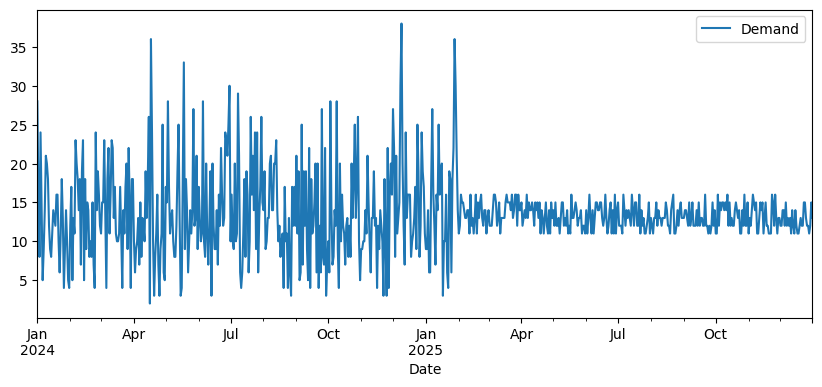

In [22]:
sample_sku = df["SKU"].iloc[0]

df[df["SKU"] == sample_sku].plot(
    x="Date",
    y="Demand",
    figsize=(10,4)
)

In [23]:
import pandas as pd

df = pd.read_csv("../data/processed/daily_demand.csv")
df["Date"] = pd.to_datetime(df["Date"])

missing_report = {}

for sku in df["SKU"].unique():

    sku_df = df[df["SKU"] == sku].sort_values("Date")

    expected = pd.date_range(
        sku_df["Date"].min(),
        sku_df["Date"].max(),
        freq="D"
    )

    missing = expected.difference(sku_df["Date"])

    if len(missing) > 0:
        missing_report[sku] = len(missing)

missing_report

{}

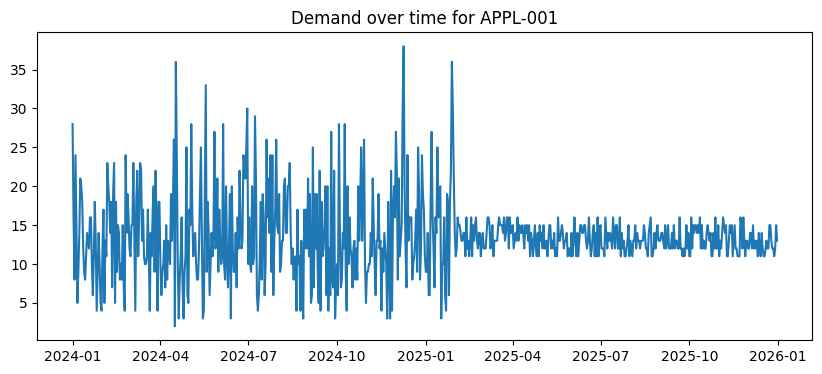

In [24]:
import matplotlib.pyplot as plt

sku = df["SKU"].iloc[0]

sku_df = df[df["SKU"] == sku]

plt.figure(figsize=(10,4))
plt.plot(sku_df["Date"], sku_df["Demand"])
plt.title(f"Demand over time for {sku}")
plt.show()

In [26]:
import pandas as pd

df = pd.read_csv("../data/processed/forecast_2025.csv")

print(df.shape)
print(df.head())
print(df["Date"].min(), df["Date"].max())

(52833, 4)
         Date  Forecast_Demand       SKU SKU_Name
0  2024-01-01        14.399999  APPL-001      NaN
1  2024-01-02        14.438588  APPL-001      NaN
2  2024-01-03        14.152518  APPL-001      NaN
3  2024-01-04        13.240946  APPL-001      NaN
4  2024-01-05        13.617313  APPL-001      NaN
2024-01-01 2026-01-30
